# BERT LLM Hallucination Detector

### Imports

In [17]:
import os
import json
import time
import ast
import unicodedata
from datetime import datetime
import random
import numpy as np
from datasets import load_dataset
from transformers import AutoTokenizer
from dotenv import load_dotenv
from tavily import TavilyClient
from langdetect import detect, DetectorFactory
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.11.0+cu128
12.8
True
NVIDIA GeForce RTX 5070 Laptop GPU


### Step 1: Initialization and Setup

In [18]:
load_dotenv()
API_Tavily = os.getenv("API_Tavily")
api_keys = [
        os.getenv("GROQ_API_KEY1"),
        os.getenv("GROQ_API_KEY2"),
        os.getenv("GROQ_API_KEY3"),
        os.getenv("GROQ_API_KEY4"),
        os.getenv("GROQ_API_KEY5")
    ]
DetectorFactory.seed = 0

# Initialize clients and tokenizer
client = TavilyClient(API_Tavily)
tokenizer = AutoTokenizer.from_pretrained("bert-base-multilingual-uncased")

# Initialize Translation/Groq LLM
model = ChatGroq(
    api_key=api_keys[0],
    model="llama-3.1-8b-instant",
    temperature=0.0,
    max_retries=2,
)

### Step 2: Data Loading

In [19]:
dataset = load_dataset("Helsinki-NLP/mu-shroom", "all")

# Access splits
train = dataset["train_unlabeled"]
val = dataset["validation"]
test = dataset["test"]

# add indices to the dataset
def add_id(example, idx):
    example["id"] = idx
    return example

# normalize the characters in the dataset to avoid issues with special characters
def normalize_text(text):
    if text is None:
        return ""

    # Normalize Unicode representation
    text = unicodedata.normalize("NFC", text)

    # Normalize quotation marks/apostrophes
    replacements = {
        "’": "'",
        "‘": "'",
        "“": '"',
        "”": '"',
        "„": '"',
        "‹": "'",
        "›": "'",
        "\u00A0": " ",  # non-breaking space
        "\u200B": "",   # zero-width space
        "\u200D": "",   # zero-width joiner
    }

    for old, new in replacements.items():
        text = text.replace(old, new)

    return text.strip()


train = train.map(
    add_id,
    with_indices=True
)

### Step 3: Translation and Normalization Logic

In [20]:
def detect_language(text):
    """
    Detect language using ISO-639-1 codes:
    en, de, fr, hi, etc.
    """
    try:
        return detect(text)
    except Exception:
        return "unknown"

def translate_text(text, target_language):
    messages = [
    ("system", f"You are a helpful translator. Translate the user sentence to {target_language}."),
    ("human", text),
    ]
    response = model.invoke(messages)
    return response.content.strip()

def normalize_answer_language(question, answer):
    """
    Check if question and answer languages match.
    Translate answer if needed.
    """
    question_lang = detect_language(question)
    answer_lang = detect_language(answer)

    if question_lang == answer_lang:
        return answer

    return translate_text(
        answer,
        question_lang
    )

def normalize_special_characters(example):

    example["model_input"] = normalize_text(
        example["model_input"]
    )

    example["model_output_text"] = normalize_text(
        example["model_output_text"]
    )

    example["reference_answer"] = normalize_text(
        example["reference_answer"]
    )

    return example

### Step 4: Ground Truth Retrieval (Tavily)

In [21]:
unique_questions = list(set(train["model_input"]))

# Get reference first old else new
if os.path.exists("reference_map.json"):
    with open("reference_map.json", "r", encoding="utf-8") as f:
        reference_map = json.load(f)
else:
    reference_map = {}

# Search questions
for question in unique_questions:
    # Skip already searched questions
    if question in reference_map:
        continue

    # Get answers
    try:
        response = client.search(
            query=question,
            include_answer="basic",
            search_depth="basic"
        )
        answer = response.get("answer") or "No answer returned"
        answer = normalize_answer_language(question, answer)
        reference_map[question] = answer
        
        # Save immediately after each successful search
        with open("reference_map.json", "w", encoding="utf-8") as f:
            json.dump(reference_map, f, indent=4, ensure_ascii=False)
            
    except Exception as e:
        continue


### Step 5: Map References to Dataset

In [22]:
def add_reference(example):
    example["reference_answer"] = reference_map[example["model_input"]]
    return example

train = train.map(add_reference)
train = train.map(normalize_special_characters)

In [23]:
train[1000]

{'id': 1000,
 'lang': 'ES',
 'model_input': '¿Qué tipo de bebida es el Capitan Morgan?',
 'model_output_text': 'Captain Morgan es una marca de ron, que es un tipo de bebida alcohólica destilada hecha a partir de la caña de azúcar o la remolacha azucarada. Se originó en Gales y lleva el nombre del pirata del siglo XVII, Sir Henry Morgan. La marca es conocida por sus sabores distintivos y su fuerte contenido de alcohol.',
 'model_id': 'Iker/Llama-3-Instruct-Neurona-8b-v2',
 'wikipedia_url': None,
 'soft_labels': None,
 'hard_labels': None,
 'model_output_logits': [24.1562767029,
  29.8636245728,
  25.7136325836,
  26.4448757172,
  22.5440921783,
  24.1393051147,
  19.9062595367,
  32.0728797913,
  18.5324344635,
  20.3986377716,
  25.8859920502,
  26.9128742218,
  22.8077888489,
  26.4061126709,
  23.6107997894,
  36.1078109741,
  23.5410652161,
  27.2813053131,
  30.6391525269,
  30.9397315979,
  19.7266635895,
  28.3470802307,
  31.5850448608,
  20.1085243225,
  35.6496505737,
  22.993

### Step 6: LLM Hallucination Detection Prompting

#### 6.1 Prompt Templates

In [24]:
def prompt_template(model_input,model_output_text,reference_answer):
    """
    Generate 5 prompts for hallucination detection.
    params: model_input, model_output_text, reference_answer
    return: list of 5 prompts
    """
    # default
    message1 = [
    (
    "system",
    "You are a hallucination detection assistant. Identify factual claims in an LLM-generated answer that are hallucinated when compared with the reference answer."
    ),
    (
    "user",
    f"""
    Compare the LLM answer with the reference answer.

    Return ONLY a Python list of strings:
    ["hallucinated_span_1", "hallucinated_span_2"]

    Rules:
    - hallucinated_span must be copied EXACTLY from the LLM answer.
    - Do not paraphrase or correct the text.
    - Include only false or unsupported factual claims.
    - Include complete factual claims that are false or unsupported.
    - The spans must be as short as possible, but include the complete factual claim that is false.
    - If no hallucination exists, return [].
    - Do not provide explanations.

    Question:
    {model_input}

    LLM Answer:
    {model_output_text}

    Reference Answer:
    {reference_answer}
    """
    )
    ]
    # Atomic claim decomposition
    message2 = [
    (
    "system",
    "You are a hallucination detection assistant. Identify factual claims in an LLM-generated answer that are hallucinated when compared with the reference answer."
    ),
    (
    "user",
    f"""
    Compare the LLM answer with the reference answer.

    Return ONLY a Python list of strings:
    ["hallucinated_span_1", "hallucinated_span_2"]

    Rules:
    - Copy spans exactly from the LLM answer.
    - Identify each individual false factual claim separately.
    - If a sentence contains multiple hallucinated facts, return separate spans.
    - Do not include correct parts of the sentence.
    - Do not mark equivalent statements as hallucinations.
    - If no hallucination exists, return [].
    - Do not provide explanations.

    Question:
    {model_input}

    LLM Answer:
    {model_output_text}

    Reference Answer:
    {reference_answer}
    """
    )
    ]
    # Strict contradiction detector
    message3 = [
    (
    "system",
    "You are a hallucination detection assistant. Identify factual claims in an LLM-generated answer that are hallucinated when compared with the reference answer."
    ),
    (
    "user",
    f"""
    Compare the LLM answer with the reference answer.

    Return ONLY a Python list of strings:
    ["hallucinated_span_1", "hallucinated_span_2"]

    Rules:
    - Copy spans exactly from the LLM answer.
    - Only return claims that directly contradict the reference answer.
    - Do not mark missing information as hallucination.
    - Do not mark different wording with the same meaning as hallucination.
    - Avoid guessing.
    - If no direct contradiction exists, return [].
    - Do not provide explanations.

    Question:
    {model_input}

    LLM Answer:
    {model_output_text}

    Reference Answer:
    {reference_answer}
    """
    )
    ]
    # Complete factual claim
    message4 = [
    (
    "system",
    "You are a hallucination detection assistant. Identify factual claims in an LLM-generated answer that are hallucinated when compared with the reference answer."
    ),
    (
    "user",
    f"""
    Compare the LLM answer with the reference answer.

    Return ONLY a Python list of strings:
    ["hallucinated_span_1", "hallucinated_span_2"]

    Rules:
    - Copy spans exactly from the LLM answer.
    - Return complete factual claims that are false or unsupported.
    - Include enough context to understand why the claim is wrong.
    - Do not return isolated words or numbers.
    - Do not mark correct paraphrases as hallucinations.
    - If no hallucination exists, return [].
    - Do not provide explanations.

    Question:
    {model_input}

    LLM Answer:
    {model_output_text}

    Reference Answer:
    {reference_answer}
    """
    )
    ]
    # smallest hall
    message5 = [
    (
    "system",
    "You are a hallucination detection assistant. Identify factual claims in an LLM-generated answer that are hallucinated when compared with the reference answer."
    ),
    (
    "user",
    f"""
    Compare the LLM answer with the reference answer.

    Return ONLY a Python list of strings:
    ["hallucinated_span_1", "hallucinated_span_2"]

    Rules:
    - Copy spans exactly from the LLM answer.
    - Return only statements that are factually incorrect or unsupported.
    - Select the smallest span that contains the hallucinated information.
    - Do not include surrounding correct information.
    - Do not mark paraphrases or equivalent meanings as hallucinations.
    - If no hallucination exists, return [].
    - Do not provide explanations.

    Question:
    {model_input}

    LLM Answer:
    {model_output_text}

    Reference Answer:
    {reference_answer}
    """
    )
    ]
    # Context-aware balanced annotation
    message6 = [(
    "system",
    "You are a hallucination detection assistant. Identify factual claims in an LLM-generated answer that are hallucinated when compared with the reference answer."
    ),
    (
    "user",
    f"""
    Compare the LLM answer with the reference answer.

    Return ONLY a Python list of strings:
    ["hallucinated_span_1", "hallucinated_span_2"]

    Rules:
    - Copy spans exactly from the LLM answer.
    - Return the shortest span that still represents a complete false factual claim.
    - Consider the meaning of the statement, not only exact wording.
    - Do not mark correct explanations, paraphrases, or logical consequences of the reference answer.
    - Do not include unsupported speculation unless it conflicts with the reference answer.
    - If no hallucination exists, return [].
    - Do not provide explanations.

    Question:
    {model_input}

    LLM Answer:
    {model_output_text}

    Reference Answer:
    {reference_answer}
    """
    )
    ]

    # get 2 random messages from the 6 messages
    messages = random.sample([message1,message2,message3,message4,message5,message6], 2)
    # messages = [message1,message2,message3,message4,message5,message6]

    return messages

#### 6.2 Model setup

In [25]:
def create_llm_models():
    """
    Returns a dictionary of LLM models with their configurations for hallucination detection.
    Example: {model_name: ChatGroq(...), ...}
    """
    models = {

        "qwen3.6-27b": ChatGroq(
            api_key=api_keys[1],
            model="qwen/qwen3.6-27b",
            temperature=0,
            max_tokens=None,
            reasoning_effort="none",
            reasoning_format="hidden",
            timeout=None,
            max_retries=2,
        ),

        "llama-3.3-70b": ChatGroq(
            api_key=api_keys[4],
            model="llama-3.3-70b-versatile",
            temperature=0,
            max_tokens=None,
            timeout=None,
            max_retries=2,
        ),

        "gpt-oss-120b": ChatGroq(
            api_key=api_keys[3],
            model="openai/gpt-oss-120b",
            temperature=0,
            max_tokens=None,
            reasoning_effort="low",
            reasoning_format="hidden",
            timeout=None,
            max_retries=2,
        )
    }

    return models

Helper functions for LLM hallucination detection

In [26]:
def parse_spans(output):
    """
    Convert LLM response into list of hallucinated spans.
    example: string from llm('["span1", "span2"]') -> ["span1", "span2"]
    """

    try:
        spans = ast.literal_eval(output.strip())
    except Exception:
        return []

    cleaned = []

    for span in spans:

        # if model returns tuple accidentally
        if isinstance(span, (tuple, list)):
            span = span[0]

        if isinstance(span, str):
            cleaned.append(span)

    return cleaned

OUTPUT_FILE = "annotations.jsonl"
LOG_FILE = "annotation.log"


def log(message):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(f"[{timestamp}] {message}\n")

    print(message)


def load_completed_samples():

    completed = set()

    if os.path.exists(OUTPUT_FILE):

        with open(OUTPUT_FILE, "r", encoding="utf-8") as f:

            for line in f:

                try:
                    completed.add(json.loads(line)["sample_id"])
                except Exception:
                    pass

    return completed


def annotate_sample(sample_id, sample, llm_models):

    prompts = prompt_template(
        sample["model_input"],
        sample["model_output_text"],
        sample["reference_answer"]
    )

    metadata = []

    for model_name, llm in llm_models.items():

        for prompt_id, prompt in enumerate(prompts):

            max_retry = 5

            for attempt in range(max_retry):

                try:

                    response = llm.invoke(prompt)

                    spans = parse_spans(response.content)

                    metadata.append({
                        "model": model_name,
                        "prompt": prompt_id,
                        "spans": spans
                    })

                    log(
                        f"Sample {sample_id} | "
                        f"{model_name} | "
                        f"Prompt {prompt_id} | "
                        f"SUCCESS | "
                        f"{len(spans)} spans"
                    )

                    break

                except Exception as e:

                    msg = str(e)

                    log(
                        f"Sample {sample_id} | "
                        f"{model_name} | "
                        f"Prompt {prompt_id} | "
                        f"FAILED | "
                        f"{msg}"
                    )

                    if attempt == max_retry - 1:

                        metadata.append({
                            "model": model_name,
                            "prompt": prompt_id,
                            "spans": [],
                            "error": msg
                        })

                    else:

                        wait_time = 60

                        log(
                            f"Retry {attempt+1}/{max_retry} "
                            f"after {wait_time} seconds..."
                        )

                        time.sleep(wait_time)

            # stay safely below Groq RPM limits
            time.sleep(2.2)

    return {
        "sample_id": sample_id,
        "model_input": sample["model_input"],
        "model_output_text": sample["model_output_text"],
        "reference_answer": sample["reference_answer"],
        "metadata": metadata
    }

#### 6.3 Annotation of soft and hard labels for llm output

In [27]:
# def annotate_sample(sample, llm_models):
#     """
#     Annotate a sample with hallucination detection labels using multiple LLM models and prompts.
#     input: sample (dict), llm_models (dict)
#     output: dict with text, soft_labels, hard_labels, and metadata
#     """

#     text = sample["model_output_text"]

#     prompts = prompt_template(
#         sample["model_input"],
#         sample["model_output_text"],
#         sample["reference_answer"]
#     )

#     all_character_labels = []

#     metadata = []


#     for model_name, llm in llm_models.items():

#         for prompt_id, prompt in enumerate(prompts):

#             response = llm.invoke(prompt)

#             spans = parse_spans(response.content)

#             labels = spans_to_character_labels(
#                 text,
#                 spans
#             )

#             all_character_labels.append(labels)


#             metadata.append({
#                 "model": model_name,
#                 "prompt": prompt_id,
#                 "spans": spans
#             })


#     # shape:
#     # (18, number_of_characters)
#     label_matrix = np.stack(all_character_labels)


#     soft_labels = label_matrix.mean(axis=0)

#     hard_labels = (
#         soft_labels >= 0.5
#     ).astype(np.int8)


#     return {
#         "text": text,
#         "soft_labels": soft_labels.tolist(),
#         "hard_labels": hard_labels.tolist(),
#         "metadata": metadata
#     }

### 7. Finally Annotate entire Dataset

In [28]:
# llm_models = create_llm_models()

# completed = load_completed_samples()

# for sample in train:
#     sample_id = sample["id"]
#     if sample_id in completed:
#         print(f"Skipping sample {sample_id}")
#         continue

#     print(f"Processing sample {sample_id}")

#     result = annotate_sample(
#         sample_id,
#         sample,
#         llm_models
#     )

#     with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
#         f.write(
#             json.dumps(
#                 result,
#                 ensure_ascii=False
#             ) + "\n"
#         )

#     log(f"Saved sample {sample_id}")

8. Load annotated spans from JSONL and make a huggingface dataset later*

In [29]:
import json

# load the annotations from jsonl file
def load_annotations(annotation_file):

    annotations = []

    with open(annotation_file, "r", encoding="utf-8") as f:
        for line in f:
            annotations.append(json.loads(line))

    return annotations
annotations = load_annotations(
    "annotations.jsonl"
)

# filter the data based on annotations found in the annotations.jsonl file
annotated_ids = {ann["sample_id"] for ann in annotations}
filtered_data = train.filter(lambda x: x["id"] in annotated_ids)
print(f"Number of annotations: {len(annotations)}")
print(f"First annotation: {annotations[0]}")  # Print the first annotation for verification
print(f"Number of filtered training samples: {len(filtered_data)}")  # Print the number of filtered training samples

annotations_dict = {
    ann["sample_id"]: ann
    for ann in annotations
}

Number of annotations: 237
First annotation: {'sample_id': 0, 'model_input': 'Do all arthropods have antennae?', 'model_output_text': ' Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna. ', 'reference_answer': 'No, not all arthropods have antennae. Insects and crustaceans usually have antennae, but some arthropods such as spiders and scorpions do not.', 'metadata': [{'model': 'qwen3.6-27b', 'prompt': 0, 'spans': ['Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna.']}, {'model': 'qwen3.6-27b', 'prompt': 1, 'spans': ['Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna.']}, {'model': 'qwen3.6-27b', 'prompt': 2, 'spans': ['Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna.']}, {'model': 'qwen3.6-27b', 'prompt': 3, 'spans': ['all insects and arachnids (including spiders, scorpions, and ticks) have a

9. Convert detected text spans → character-level labels

In [30]:
def spans_to_character_labels(text, spans):
    labels = np.zeros(len(text), dtype=np.int8)

    for span in spans:

        if not span:
            continue

        start = text.find(span)

        if start == -1:
            continue

        end = start + len(span)

        labels[start:end] = 1

    return labels

def apply_character_labels_to_dataset(dataset, annotations):

    annotations_dict = {
        ann["sample_id"]: ann
        for ann in annotations
    }

    def add_labels(example):

        ann = annotations_dict[example["id"]]

        text = example["model_output_text"]

        all_character_labels = []

        for meta in ann["metadata"]:

            spans = meta.get("spans", [])

            char_labels = spans_to_character_labels(
                text,
                spans
            )

            all_character_labels.append(char_labels)


        label_matrix = np.stack(all_character_labels)


        soft_labels = label_matrix.mean(axis=0)

        hard_labels = (
            soft_labels >= 0.7
        ).astype(np.int8)


        example["soft_labels"] = soft_labels.tolist()
        example["hard_labels"] = hard_labels.tolist()


        return example


    return dataset.map(add_labels)


In [31]:
filtered_train = apply_character_labels_to_dataset(
    filtered_data,
    annotations
)

Map:   0%|          | 0/237 [00:00<?, ? examples/s]

In [32]:
sample = filtered_train[0]

print(sample["model_output_text"])

print("\nSoft:")
print(sample["soft_labels"])

print("\nHard:")
print(sample["hard_labels"])

Yes, all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna.

Soft:
[0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 0.6666666666666666, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.3888888888888889]

Hard:
[0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0]


Save Hugging face datase
but we need this format
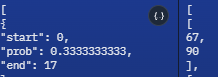
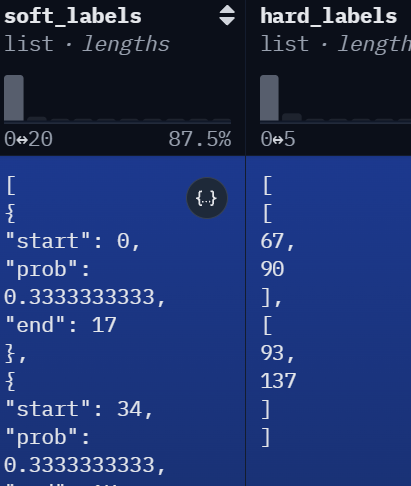

In [33]:
def labels_to_spans(text, labels):
    spans = []

    start = None

    for i, label in enumerate(labels):

        if label == 1 and start is None:
            start = i

        elif label == 0 and start is not None:
            spans.append({
                "start": start,
                "end": i,
                "text": text[start:i]
            })
            start = None

    # last span
    if start is not None:
        spans.append({
            "start": start,
            "end": len(text),
            "text": text[start:]
        })

    return spans

In [34]:
sample = filtered_train[0]

spans = labels_to_spans(
    sample["model_output_text"],
    sample["hard_labels"]
)

for span in spans:
    print(span)

{'start': 5, 'end': 98, 'text': 'all insects and arachnids (including spiders, scorpions, and ticks) have at least one antenna'}


In [35]:
filtered_train.save_to_disk(
    "temp_mu_shroom_llm_annotated_train"
)

Saving the dataset (0/1 shards):   0%|          | 0/237 [00:00<?, ? examples/s]

load the dataset and annotations

In [36]:
from datasets import load_from_disk

dataset = load_from_disk(
    "temp_mu_shroom_llm_annotated_train"
)

# Finally bert model training and evaluation



12. Train BERT/XLM-R token classification model on the annotated dataset using hard/soft labels

1. Tokenize the dataset using the BERT tokenizer

In [37]:
from transformers import AutoTokenizer, AutoModelForTokenClassification
model_name = "bert-base-multilingual-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=2
)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: bert-base-multilingual-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
bert.pooler.dense.weight                   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those para

2. Offset mapping

In [38]:
def tokenize_and_align_labels(example):

    text = example["model_output_text"]

    char_labels = example["hard_labels"]

    encoding = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=512,
        return_offsets_mapping=True
    )

    token_labels = []

    for start, end in encoding["offset_mapping"]:

        # special tokens
        if start == end:
            token_labels.append(-100)
            continue


        # character overlap
        labels = char_labels[start:end]

        if len(labels) == 0:
            token_labels.append(0)

        else:
            # if any character is hallucinated
            token_labels.append(
                1 if sum(labels) > 0 else 0
            )


    encoding["labels"] = token_labels

    # remove offset mapping
    encoding.pop("offset_mapping")

    return encoding

3. Apply tokenizer

In [39]:
tokenized_dataset = filtered_train.map(
    tokenize_and_align_labels,
    remove_columns=filtered_train.column_names
)
print(tokenized_dataset[0])

Map:   0%|          | 0/237 [00:00<?, ? examples/s]

{'input_ids': [101, 31617, 117, 10367, 19531, 10110, 12805, 65475, 13067, 113, 11371, 37451, 117, 91842, 10107, 117, 10110, 12780, 28144, 114, 10574, 10160, 16331, 10399, 86161, 119, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

4. tarin test split

In [40]:
dataset_split = tokenized_dataset.train_test_split(
    test_size=0.2,
    seed=42
)

train_dataset = dataset_split["train"]
eval_dataset = dataset_split["test"]

5. train setup

In [41]:
from transformers import TrainingArguments, Trainer
from sklearn.metrics import precision_recall_fscore_support

training_args = TrainingArguments(
    output_dir="./mbert-hallucination-detector",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    fp16=True,
)

6. train model

In [46]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)
trainer.train()
trainer.save_model("./mbert_hallucination_detector")
tokenizer.save_pretrained("./mbert_hallucination_detector")

Epoch,Training Loss,Validation Loss
1,0.341151,0.566215
2,0.191958,0.433354
3,0.133708,0.455293
4,0.103487,0.531125
5,0.080902,0.537339


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./mbert_hallucination_detector\\tokenizer_config.json',
 './mbert_hallucination_detector\\tokenizer.json')

In [43]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch
0.226163,0.397543,5


{'eval_loss': 0.3975425064563751}

In [47]:
trainer.predict(eval_dataset)

PredictionOutput(predictions=array([[[ 0.35058594, -0.3725586 ],
        [ 1.4541016 , -1.2988281 ],
        [ 1.5644531 , -1.4462891 ],
        ...,
        [ 0.2578125 , -0.38305664],
        [-0.01931763, -0.359375  ],
        [ 0.00424576, -0.22497559]],

       [[ 0.59765625, -0.57470703],
        [ 2.1660156 , -2.1972656 ],
        [ 2.5917969 , -2.328125  ],
        ...,
        [ 1.3632812 , -1.1328125 ],
        [ 1.2939453 , -1.0810547 ],
        [ 1.1552734 , -1.0283203 ]],

       [[ 0.08850098, -0.01828003],
        [-1.1386719 ,  1.2753906 ],
        [-1.484375  ,  1.9042969 ],
        ...,
        [ 0.40405273, -0.11914062],
        [ 0.3540039 , -0.07843018],
        [-0.11474609,  0.09503174]],

       ...,

       [[ 0.6982422 , -0.58984375],
        [ 1.9707031 , -2.3300781 ],
        [ 2.2285156 , -1.9892578 ],
        ...,
        [ 0.63183594, -0.6591797 ],
        [ 0.69921875, -0.6928711 ],
        [ 0.66064453, -0.64160156]],

       [[ 0.59472656, -0.5415039 ]

# Evaluation

In [49]:
from transformers import AutoModelForTokenClassification

model = AutoModelForTokenClassification.from_pretrained(
    "./mbert_hallucination_detector"
)

model.to("cuda")
model.eval()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(105879, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, e

In [50]:
def tokenize_and_align_labels(example):

    text = example["model_output_text"]
    char_labels = example["hard_labels"]

    encoding = tokenizer(
        text,
        truncation=True,
        max_length=512,
        return_offsets_mapping=True
    )

    token_labels = []

    for start,end in encoding["offset_mapping"]:

        if start == end:
            token_labels.append(-100)
            continue

        token_chars = char_labels[start:end]

        if any(token_chars):
            token_labels.append(1)
        else:
            token_labels.append(0)

    encoding["labels"] = token_labels

    encoding.pop("offset_mapping")

    return encoding

In [51]:
eval_dataset = filtered_train.map(
    tokenize_and_align_labels,
    remove_columns=filtered_train.column_names
)

Map:   0%|          | 0/237 [00:00<?, ? examples/s]

In [52]:
from torch.utils.data import DataLoader
import torch


loader = DataLoader(
    eval_dataset,
    batch_size=8
)


all_preds=[]
all_labels=[]


with torch.no_grad():

    for batch in loader:

        batch = {
            k:v.to("cuda")
            for k,v in batch.items()
        }

        outputs = model(**batch)

        predictions = torch.argmax(
            outputs.logits,
            dim=-1
        )


        all_preds.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            batch["labels"].cpu().numpy()
        )

RuntimeError: each element in list of batch should be of equal size